# 02 - MapReduce thuần (không dùng Spark)

Cài đặt thủ công mô hình **map → shuffle → reduce** bằng Python + `multiprocessing`
(không dùng `SparkContext`/DataFrame) để minh hoạ nguyên lý MapReduce trước khi
chuyển sang xử lý bằng Spark ở các bước sau.

Bài toán: tổng hợp (SUM) doanh số bán hàng từ `data/raw/train.csv` (~3 triệu dòng) theo 3 khoá khác nhau:

1. Theo **cửa hàng** (`store_nbr`)
2. Theo **nhóm hàng** (`family`)
3. Theo **tháng** (`yyyy-mm`) — góc nhìn chuỗi thời gian sơ bộ cho đề tài

Cách cài đặt: mỗi tiến trình con đóng vai trò 1 *mapper* — đọc 1 khối dòng CSV, áp
dụng hàm map, rồi **combine cục bộ** (cộng dồn ngay trong tiến trình để giảm dữ
liệu truyền về). Tiến trình chính đóng vai trò *reducer* — gộp (shuffle + reduce)
kết quả cục bộ của tất cả mapper thành kết quả cuối. Cài đặt nằm ở
[`src/mapreduce/mapreduce_thuan.py`](../src/mapreduce/mapreduce_thuan.py) (engine
chung) và [`src/mapreduce/bai_toan_doanh_so.py`](../src/mapreduce/bai_toan_doanh_so.py)
(hàm map riêng cho bài toán này).

In [1]:
import os
import sys
import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

THU_MUC_HIEN_TAI = Path.cwd()
GOC = THU_MUC_HIEN_TAI.parent if THU_MUC_HIEN_TAI.name == "notebooks" else THU_MUC_HIEN_TAI
sys.path.append(str(GOC / "src"))

from cau_hinh import DATA_RAW, DATA_PARQUET, OUT_TABLES, OUT_FIGURES, tao_thu_muc
from mapreduce.mapreduce_thuan import chay_mapreduce_tong
from mapreduce.bai_toan_doanh_so import map_theo_cua_hang, map_theo_nhom_hang, map_theo_thang

tao_thu_muc()
DUONG_DAN_TRAIN = DATA_RAW / "train.csv"
SO_TIEN_TRINH = os.cpu_count() or 4
print("So tien trinh (mapper) su dung:", SO_TIEN_TRINH)

So tien trinh (mapper) su dung: 16


## Chạy MapReduce cho 3 bài toán

In [2]:
cac_bai_toan = {
    "cua_hang": map_theo_cua_hang,
    "nhom_hang": map_theo_nhom_hang,
    "thang": map_theo_thang,
}

ket_qua = {}
for ten, ham_map in cac_bai_toan.items():
    t0 = time.time()
    tong, dem = chay_mapreduce_tong(str(DUONG_DAN_TRAIN), ham_map,
                                     kich_thuoc_khoi=200_000, so_tien_trinh=SO_TIEN_TRINH)
    thoi_gian = round(time.time() - t0, 2)
    ket_qua[ten] = (tong, dem)
    tong_so_dong = sum(dem.values())
    print(f"[{ten:<10}] so khoa={len(tong):<4} tong_so_dong={tong_so_dong:<9} thoi_gian={thoi_gian}s")

[cua_hang  ] so khoa=54   tong_so_dong=3000888   thoi_gian=11.05s


[nhom_hang ] so khoa=33   tong_so_dong=3000888   thoi_gian=10.3s


[thang     ] so khoa=56   tong_so_dong=3000888   thoi_gian=9.88s


## Lưu bảng kết quả

In [3]:
bang = {}
for ten, (tong, dem) in ket_qua.items():
    df = pd.DataFrame(
        [(khoa, tong[khoa], dem[khoa]) for khoa in tong],
        columns=[ten, "tong_doanh_so", "so_dong"],
    ).sort_values("tong_doanh_so", ascending=False).reset_index(drop=True)
    bang[ten] = df
    duong_dan_ra = OUT_TABLES / f"mapreduce_theo_{ten}.csv"
    df.to_csv(duong_dan_ra, index=False, encoding="utf-8-sig")
    print("Da luu:", duong_dan_ra)

bang["cua_hang"].head()

Da luu: C:\Users\Bour Bon\Downloads\StoreSales_BigData_GD1\StoreSales_BigData\outputs\tables\mapreduce_theo_cua_hang.csv
Da luu: C:\Users\Bour Bon\Downloads\StoreSales_BigData_GD1\StoreSales_BigData\outputs\tables\mapreduce_theo_nhom_hang.csv
Da luu: C:\Users\Bour Bon\Downloads\StoreSales_BigData_GD1\StoreSales_BigData\outputs\tables\mapreduce_theo_thang.csv


,cua_hang,tong_doanh_so,so_dong
0,44,6.208755e+07,55572
1,45,5.449801e+07,55572
2,47,5.094831e+07,55572
3,3,5.048191e+07,55572
4,49,4.342010e+07,55572


## Đối chiếu với Spark `groupBy` (kiểm tra tính đúng đắn)

Dùng lại `data/parquet/train` đã tạo ở notebook 01 để tính tổng doanh số theo
cửa hàng bằng Spark, rồi so sánh từng khoá với kết quả MapReduce thuần — sai lệch
phải xấp xỉ 0 (chỉ chênh lệch làm tròn số thực).

In [4]:
from spark_session import tao_spark
from pyspark.sql import functions as F

spark = tao_spark("02_MapReduce_DoiChieu")
df_train = spark.read.parquet(str(DATA_PARQUET / "train"))

spark_agg = {
    str(r["store_nbr"]): r["tong_doanh_so"]
    for r in df_train.groupBy("store_nbr").agg(F.sum("sales").alias("tong_doanh_so")).collect()
}

tong_mapreduce, _ = ket_qua["cua_hang"]
sai_lech_max = max(abs(gia_tri - spark_agg[khoa]) for khoa, gia_tri in tong_mapreduce.items())

print("So khoa MapReduce:", len(tong_mapreduce), "| So khoa Spark:", len(spark_agg))
print("Sai lech tuyet doi lon nhat (MapReduce vs Spark groupBy):", sai_lech_max)

assert set(tong_mapreduce.keys()) == set(spark_agg.keys())
assert sai_lech_max < 1e-6, "MapReduce va Spark khong khop!"
print("Doi chieu MapReduce vs Spark: KHOP")

spark.stop()

So khoa MapReduce: 54 | So khoa Spark: 54
Sai lech tuyet doi lon nhat (MapReduce vs Spark groupBy): 2.9802322387695312e-08
Doi chieu MapReduce vs Spark: KHOP


## Biểu đồ minh hoạ

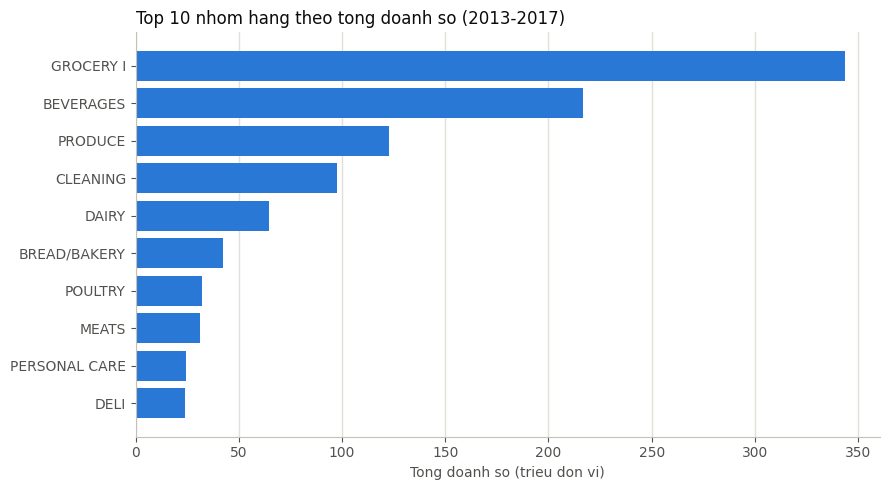

In [5]:
MAU_CHINH = "#2a78d6"
MAU_LUOI = "#e1e0d9"
MAU_TRUC = "#c3c2b7"
MAU_CHU_PHU = "#52514e"
MAU_CHU_CHINH = "#0b0b0b"

top10_nhom_hang = bang["nhom_hang"].head(10).iloc[::-1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top10_nhom_hang["nhom_hang"], top10_nhom_hang["tong_doanh_so"] / 1e6, color=MAU_CHINH)
ax.set_xlabel("Tong doanh so (trieu don vi)", color=MAU_CHU_PHU)
ax.set_title("Top 10 nhom hang theo tong doanh so (2013-2017)", color=MAU_CHU_CHINH, loc="left")
ax.grid(axis="x", color=MAU_LUOI, linewidth=1, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color(MAU_TRUC)
ax.tick_params(colors=MAU_CHU_PHU)
fig.tight_layout()
fig.savefig(OUT_FIGURES / "mapreduce_top10_nhom_hang.png", dpi=150)
plt.show()

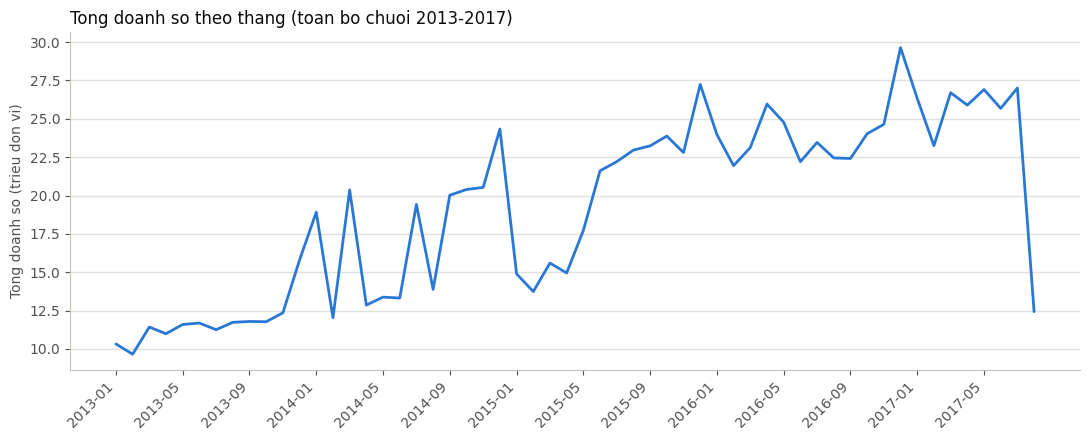

In [6]:
theo_thang = bang["thang"].sort_values("thang").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(theo_thang["thang"], theo_thang["tong_doanh_so"] / 1e6,
        color=MAU_CHINH, linewidth=2, solid_capstyle="round")
ax.set_ylabel("Tong doanh so (trieu don vi)", color=MAU_CHU_PHU)
ax.set_title("Tong doanh so theo thang (toan bo chuoi 2013-2017)", color=MAU_CHU_CHINH, loc="left")
ax.grid(axis="y", color=MAU_LUOI, linewidth=1, zorder=0)
ax.set_axisbelow(True)
buoc_nhan = max(len(theo_thang) // 12, 1)
ax.set_xticks(theo_thang.index[::buoc_nhan])
ax.set_xticklabels(theo_thang["thang"][::buoc_nhan], rotation=45, ha="right")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color(MAU_TRUC)
ax.tick_params(colors=MAU_CHU_PHU)
fig.tight_layout()
fig.savefig(OUT_FIGURES / "mapreduce_doanh_so_theo_thang.png", dpi=150)
plt.show()